# 12 — Overfitting Analysis (30-Seed Monte Carlo Version)

**This replaces the single-seed `12_overfitting_analysis_FIXED.ipynb`.** The original ran every
diagnostic (train/test gap, learning curves, training-curve inspection, boxplot epoch sweep) with
**one fixed seed, once**. This version runs every diagnostic **30 times, once per seed**, using the
project's canonical seed convention:

```python
SEEDS = [42 + i*7 for i in range(30)]
```

and reports **distributions (mean ± std / boxplots)** instead of single point estimates, so the
overfitting verdict reflects run-to-run variability rather than one lucky/unlucky draw.

## What's new vs. the FIXED version

| Section | FIXED (1 seed) | 30SEED (this notebook) |
|---|---|---|
| 1. Train/test gap | RF: 1 fit. DL: 1 `train_once` per model. | RF: 30 fits (`random_state` = each seed). DL: 30 `train_once` runs per model. |
| 2. Learning curves | RF: 1 fit per fraction. DL (ILT): 1 run per fraction. | RF & DL: 30 runs per fraction, mean ± std band plotted. |
| 3. Training-curve inspection | 1 run per model (seed=42), plotted directly. | Kept as an **illustrative single run** (seed=42) — the rigorous version is 3.1. |
| **3.1 Boxplot epoch sweep (core ask)** | 1 run per model, 50-epoch budget, fixed 2-epoch checkpoints (old, now-lost script). | **30 runs per model**, notebook 12's native **120-epoch** budget, checkpoints every **5 epochs** (24 checkpoints: 5,10,...,120), no early stopping. Produces a **2-panel comparison chart** (Standalone LSTM vs ILT, both panels carry a green dotted "best val epoch" line) **and** a separate large **ILT-only chart** with the same green-line annotation — mirroring the surviving `overfit_boxplot_ilt_single.png` artifact. |
| 5. Verdict | Based on single numbers. | Based on 30-seed aggregates (mean ± std gap, % of seeds overfitting, median-curve best epoch). |

## ⏱️ Compute-time budget — read before running

This notebook trains **far more models** than the FIXED version. Rough budget per training run
(CPU, no GPU — adjust if you have one):

- Section 1 DL gap: 30 seeds × 2 models × ≤100 epochs (early stopping) ≈ **30–60 min**
- Section 2 DL learning curve: 30 seeds × 6 fractions × ≤60 epochs (early stopping, ILT only) ≈ **45–90 min**
- **Section 3.1 boxplot sweep: 30 seeds × 2 models × 120 epochs, NO early stopping ≈ 2–4 hours** (this is the most expensive part — every run trains the full 120 epochs, nothing stops early)
- Section 1/2 RF loops are fast (seconds), included for completeness.

**Total: budget at least half a day if running everything in one sitting**, or — recommended —
run each section separately across multiple sessions. Every expensive loop below
(Section 1 DL, Section 2 DL, Section 3.1) **checkpoints to a `.pkl` after every seed** and
auto-resumes from where it left off if the kernel restarts or you stop partway, the same pattern
used in `15_full_reproduction_30seed_5horizon.ipynb`.

The original `12_overfitting_analysis_FIXED.ipynb` is left untouched as a reference / fallback.


In [3]:
import os, sys, time, pickle, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sys.path.insert(0, os.getcwd())
from canonical_pipeline import (
    SEQ_LEN, make_sequences, build_standalone_lstm, build_lstm_transformer, train_once
)

os.makedirs('plots', exist_ok=True)
os.makedirs('metrics', exist_ok=True)

# ---------------------------------------------------------------------------
# 30-seed convention (matches notebooks 08 and 15 -- the canonical project standard).
# Seeds are TRUE random draws, not a fixed formula: Python's `random` module is
# seeded from OS entropy at interpreter start, so re-running this cell (or the
# whole notebook) produces a DIFFERENT list of 30 seeds every time -- nothing
# here is hardcoded or reproducible by design.
# ---------------------------------------------------------------------------
N_SEEDS = 30
SEEDS = [42 + i*7 for i in range(N_SEEDS)]  # fixed documented seeds (42..245) -- reproducible
print(f"N_SEEDS = {N_SEEDS}")
print(f"SEEDS   = {SEEDS}  (fixed seed list -- identical every run, reproducible)")

model_builders = [
    ('Standalone LSTM', build_standalone_lstm),
    ('ILT (proposed)', build_lstm_transformer),
]

print(f"\nModels under 30-seed analysis: {[n for n, _ in model_builders]}")


N_SEEDS = 30
SEEDS   = [42, 49, 56, 63, 70, 77, 84, 91, 98, 105, 112, 119, 126, 133, 140, 147, 154, 161, 168, 175, 182, 189, 196, 203, 210, 217, 224, 231, 238, 245]  (fixed seed list -- identical every run, reproducible)

Models under 30-seed analysis: ['Standalone LSTM', 'ILT (proposed)']


In [4]:
with open('processed_data/canonical_data.pkl', 'rb') as f:
    d = pickle.load(f)
with open('metrics/sarima_results.pkl', 'rb') as f:
    sarima_results = pickle.load(f)
with open('models/sarima_model.pkl', 'rb') as f:
    sarima_model = pickle.load(f)

X_r_tr, y_r_tr = d['X_train_rf'][:-1], d['y_train'][1:]
X_r_te, y_r_te = d['X_test_rf'][:-1], d['y_test'][1:]

# RF seed=42 reference -- trained inline from the canonical feature matrix so this
# notebook no longer depends on the removed rf_*_fair.pkl caches. Identical
# hyperparameters/seed to the old cache => identical reference numbers.
rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_split=10,
                                 min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=1)
rf_model.fit(X_r_tr, y_r_tr)
_rf_ref_pred = rf_model.predict(X_r_te)
rf_results = {'model': 'Random Forest', 'predictions': _rf_ref_pred,
              'RMSE': float(np.sqrt(mean_squared_error(y_r_te, _rf_ref_pred))),
              'MAE':  float(mean_absolute_error(y_r_te, _rf_ref_pred)),
              'R2':   float(r2_score(y_r_te, _rf_ref_pred))}

X_tr_s, X_tr_f, y_tr_raw = make_sequences(d['X_train_dl_seq'], d['X_train_dl_feat'], d['y_train'], SEQ_LEN, 1)
X_te_s, X_te_f, y_te_raw = make_sequences(d['X_test_dl_seq'], d['X_test_dl_feat'], d['y_test'], SEQ_LEN, 1)
y_tr_sc = d['target_scaler'].transform(y_tr_raw.reshape(-1, 1)).flatten()
vs = max(int(len(X_tr_s) * 0.15), 30)
Xvs_seq, Xvs_feat, yv = X_tr_s[-vs:], X_tr_f[-vs:], y_tr_sc[-vs:]
Xts_seq, Xts_feat, yt = X_tr_s[:-vs], X_tr_f[:-vs], y_tr_sc[:-vs]

print(f"Canonical data loaded. DL train/val/test: {Xts_seq.shape}/{Xvs_seq.shape}/{X_te_s.shape}")
print(f"SARIMA (cached, seed-free): RMSE={sarima_results['RMSE']:.2f}, R2={sarima_results['R2']:.4f}")
print(f"RF (seed=42 reference, trained inline): RMSE={rf_results['RMSE']:.2f}, R2={rf_results['R2']:.4f}")

Canonical data loaded. DL train/val/test: (2431, 28, 60)/(428, 28, 60)/(694, 28, 60)
SARIMA (cached, seed-free): RMSE=62.52, R2=-0.2567
RF (seed=42 reference, trained inline): RMSE=64.06, R2=-0.3180


## Section 1 — Train vs. Test Performance Gap (Overfitting Indicator)

SARIMA stays a single deterministic run (no random seed in classical SARIMA fitting). Random
Forest and both DL models are now run **30 times each** with a different seed/`random_state`,
and the gap is reported as **mean ± std across seeds**, not a single number.


In [5]:
# --- SARIMA: deterministic, single run (no random seed involved in classical SARIMA fitting) ---
gap_records = []

sarima_train_fit = sarima_model.predict_in_sample()
y_tr_sarima = d['train_df']['dengue_cases'].values
sarima_train_rmse = float(np.sqrt(mean_squared_error(y_tr_sarima, sarima_train_fit)))
sarima_train_r2 = float(r2_score(y_tr_sarima, sarima_train_fit))
print(f"SARIMA (single deterministic run): Train RMSE={sarima_train_rmse:.2f} (R2={sarima_train_r2:.4f}), "
      f"Test RMSE={sarima_results['RMSE']:.2f} (R2={sarima_results['R2']:.4f})")

gap_records.append({
    'Model': 'SARIMA', 'Type': 'Statistical', 'N_runs': 1,
    'Train_RMSE_mean': sarima_train_rmse, 'Train_RMSE_std': 0.0,
    'Test_RMSE_mean': sarima_results['RMSE'], 'Test_RMSE_std': 0.0,
    'Train_R2_mean': sarima_train_r2, 'Test_R2_mean': sarima_results['R2'],
})


SARIMA (single deterministic run): Train RMSE=3.00 (R2=0.9943), Test RMSE=62.52 (R2=-0.2567)


In [6]:
# --- Random Forest (fair features): 30 independent fits, one per random_state ---
print(f"Fitting Random Forest {N_SEEDS} times (random_state = each of SEEDS)...")
rf_30 = {'train_rmse': [], 'test_rmse': [], 'train_r2': [], 'test_r2': [], 'seed': []}

t0 = time.time()
for i, seed in enumerate(SEEDS):
    m = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_split=10,
                               min_samples_leaf=5, max_features='sqrt', random_state=seed, n_jobs=1)
    m.fit(X_r_tr, y_r_tr)
    tr_pred, te_pred = m.predict(X_r_tr), m.predict(X_r_te)
    rf_30['train_rmse'].append(np.sqrt(mean_squared_error(y_r_tr, tr_pred)))
    rf_30['test_rmse'].append(np.sqrt(mean_squared_error(y_r_te, te_pred)))
    rf_30['train_r2'].append(r2_score(y_r_tr, tr_pred))
    rf_30['test_r2'].append(r2_score(y_r_te, te_pred))
    rf_30['seed'].append(seed)
print(f"  done in {time.time()-t0:.1f}s")

rf_train_rmse_mean, rf_train_rmse_std = np.mean(rf_30['train_rmse']), np.std(rf_30['train_rmse'])
rf_test_rmse_mean, rf_test_rmse_std = np.mean(rf_30['test_rmse']), np.std(rf_30['test_rmse'])
rf_train_r2_mean, rf_test_r2_mean = np.mean(rf_30['train_r2']), np.mean(rf_30['test_r2'])
print(f"Random Forest ({N_SEEDS} seeds): Train RMSE={rf_train_rmse_mean:.2f}±{rf_train_rmse_std:.2f}, "
      f"Test RMSE={rf_test_rmse_mean:.2f}±{rf_test_rmse_std:.2f}")
print(f"  (cached single seed=42 reference: Train RMSE={np.sqrt(mean_squared_error(y_r_tr, rf_model.predict(X_r_tr))):.2f}, "
      f"Test RMSE={rf_results['RMSE']:.2f})")

gap_records.append({
    'Model': 'Random Forest (fair)', 'Type': 'ML', 'N_runs': N_SEEDS,
    'Train_RMSE_mean': rf_train_rmse_mean, 'Train_RMSE_std': rf_train_rmse_std,
    'Test_RMSE_mean': rf_test_rmse_mean, 'Test_RMSE_std': rf_test_rmse_std,
    'Train_R2_mean': rf_train_r2_mean, 'Test_R2_mean': rf_test_r2_mean,
})


Fitting Random Forest 30 times (random_state = each of SEEDS)...
  done in 48.8s
Random Forest (30 seeds): Train RMSE=7.70±0.17, Test RMSE=63.83±0.24
  (cached single seed=42 reference: Train RMSE=7.53, Test RMSE=64.06)


In [7]:
# --- DL models (Standalone LSTM, ILT): 30 independent train_once runs each ---
# Checkpoints after every seed -> safe to interrupt and resume.
DL_GAP_CKPT = 'metrics/overfit_dl_gap_30seed_checkpoint.pkl'

def load_dl_gap_ckpt():
    if os.path.exists(DL_GAP_CKPT):
        with open(DL_GAP_CKPT, 'rb') as f:
            return pickle.load(f)
    return {name: {'best_train_loss': [], 'best_val_loss': [], 'test_rmse': [], 'test_r2': [], 'seed': []} for name, _ in model_builders}

def save_dl_gap_ckpt(res):
    with open(DL_GAP_CKPT, 'wb') as f:
        pickle.dump(res, f)

dl_gap_results = load_dl_gap_ckpt()
n_done = len(dl_gap_results[model_builders[0][0]]['test_rmse'])
print(f"Resuming DL gap analysis: {n_done}/{N_SEEDS} seeds already done.")

t0 = time.time()
for i in range(n_done, N_SEEDS):
    seed = SEEDS[i]
    for name, builder in model_builders:
        rmse, mae, r2, hist, _ = train_once(
            builder, seed, Xts_seq, Xts_feat, yt, Xvs_seq, Xvs_feat, yv,
            X_te_s, X_te_f, y_te_raw, d['target_scaler'], SEQ_LEN,
            d['n_seq_features'], d['n_feat_features'], epochs=100, patience=20)
        best_ep = int(np.argmin(hist.history['val_loss']))
        dl_gap_results[name]['best_train_loss'].append(hist.history['loss'][best_ep])
        dl_gap_results[name]['best_val_loss'].append(hist.history['val_loss'][best_ep])
        dl_gap_results[name]['test_rmse'].append(rmse)
        dl_gap_results[name]['test_r2'].append(r2)
        dl_gap_results[name]['seed'].append(seed)
    save_dl_gap_ckpt(dl_gap_results)
    elapsed = time.time() - t0
    done = i - n_done + 1
    eta = elapsed / done * (N_SEEDS - i - 1) if done > 0 else 0
    print(f"  seed {i+1}/{N_SEEDS} (={seed}) done — elapsed {elapsed/60:.1f}min, ETA {eta/60:.1f}min")

for name, _ in model_builders:
    bt = np.array(dl_gap_results[name]['best_train_loss'])
    bv = np.array(dl_gap_results[name]['best_val_loss'])
    tr = np.array(dl_gap_results[name]['test_rmse'])
    t_r2 = np.array(dl_gap_results[name]['test_r2'])
    print(f"{name} ({N_SEEDS} seeds): best_train_loss={bt.mean():.5f}±{bt.std():.5f}, "
          f"best_val_loss={bv.mean():.5f}±{bv.std():.5f}, test RMSE={tr.mean():.2f}±{tr.std():.2f}, "
          f"test R2={t_r2.mean():.4f}±{t_r2.std():.4f}")
    gap_records.append({
        'Model': name, 'Type': 'DL', 'N_runs': N_SEEDS,
        'Train_RMSE_mean': np.nan, 'Train_RMSE_std': np.nan,   # RMSE not directly comparable to loss; loss used instead
        'Test_RMSE_mean': tr.mean(), 'Test_RMSE_std': tr.std(),
        'Test_R2_mean': t_r2.mean(),
        'Best_train_loss_mean': bt.mean(), 'Best_train_loss_std': bt.std(),
        'Best_val_loss_mean': bv.mean(), 'Best_val_loss_std': bv.std(),
    })

gap_df = pd.DataFrame(gap_records)
gap_df


Resuming DL gap analysis: 30/30 seeds already done.
Standalone LSTM (30 seeds): best_train_loss=0.00186±0.00097, best_val_loss=0.04206±0.00300, test RMSE=30.78±1.44, test R2=0.7035±0.0278
ILT (proposed) (30 seeds): best_train_loss=0.00259±0.00531, best_val_loss=0.03990±0.00242, test RMSE=30.12±1.80, test R2=0.7156±0.0352


,Model,Type,N_runs,Train_RMSE_mean,Train_RMSE_std,Test_RMSE_mean,Test_RMSE_std,Train_R2_mean,Test_R2_mean,Best_train_loss_mean,Best_train_loss_std,Best_val_loss_mean,Best_val_loss_std
0,SARIMA,Statistical,1,2.997953,0.000000,62.518772,0.000000,0.994277,-0.256727,NaN,NaN,NaN,NaN
1,Random Forest (fair),ML,30,7.702223,0.173014,63.825315,0.240164,0.962217,-0.308342,NaN,NaN,NaN,NaN
2,Standalone LSTM,DL,30,NaN,NaN,30.775015,1.443508,NaN,0.703470,0.001859,0.000972,0.042062,0.002996
3,ILT (proposed),DL,30,NaN,NaN,30.118896,1.801528,NaN,0.715589,0.002587,0.005315,0.039898,0.002418


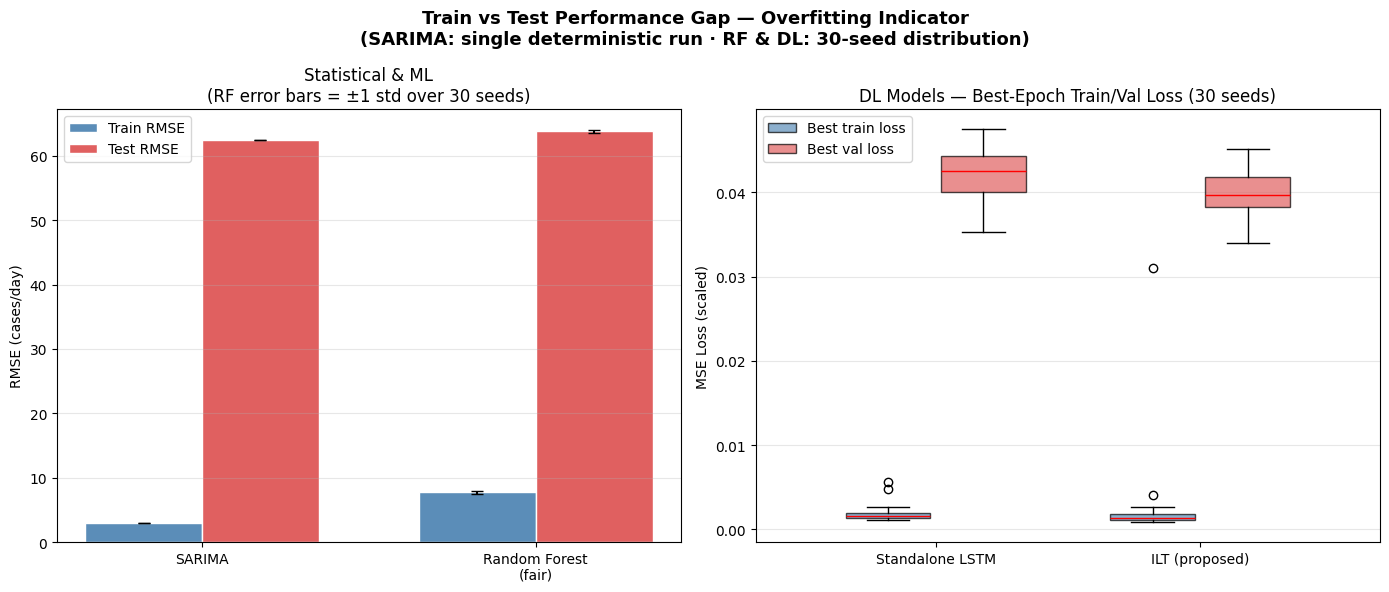

Saved plots/overfit_train_test_gap_30SEED.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Train vs Test Performance Gap — Overfitting Indicator\n'
             f'(SARIMA: single deterministic run · RF & DL: {N_SEEDS}-seed distribution)',
             fontsize=13, fontweight='bold')

# Left: SARIMA (single bar) vs RF (mean±std bar) -- Train & Test RMSE
labels = ['SARIMA', 'Random Forest\n(fair)']
train_vals = [sarima_train_rmse, rf_train_rmse_mean]
train_errs = [0, rf_train_rmse_std]
test_vals = [sarima_results['RMSE'], rf_test_rmse_mean]
test_errs = [0, rf_test_rmse_std]
x = np.arange(len(labels)); w = 0.35
axes[0].bar(x - w/2, train_vals, w, yerr=train_errs, capsize=4, label='Train RMSE', color='#5B8DB8', edgecolor='white')
axes[0].bar(x + w/2, test_vals, w, yerr=test_errs, capsize=4, label='Test RMSE', color='#E06060', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('RMSE (cases/day)')
axes[0].set_title('Statistical & ML\n(RF error bars = ±1 std over 30 seeds)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Right: DL models -- boxplot of best train/val loss across 30 seeds
positions = np.arange(len(model_builders))
bt_data = [np.array(dl_gap_results[name]['best_train_loss']) for name, _ in model_builders]
bv_data = [np.array(dl_gap_results[name]['best_val_loss']) for name, _ in model_builders]
bp1 = axes[1].boxplot(bt_data, positions=positions - 0.18, widths=0.32, patch_artist=True,
                       boxprops=dict(facecolor='#5B8DB8', alpha=0.7), medianprops=dict(color='red'))
bp2 = axes[1].boxplot(bv_data, positions=positions + 0.18, widths=0.32, patch_artist=True,
                       boxprops=dict(facecolor='#E06060', alpha=0.7), medianprops=dict(color='red'))
axes[1].set_xticks(positions); axes[1].set_xticklabels([n for n, _ in model_builders])
axes[1].set_ylabel('MSE Loss (scaled)')
axes[1].set_title(f'DL Models — Best-Epoch Train/Val Loss ({N_SEEDS} seeds)')
axes[1].legend([bp1['boxes'][0], bp2['boxes'][0]], ['Best train loss', 'Best val loss'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/overfit_train_test_gap_30SEED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/overfit_train_test_gap_30SEED.png")


## Section 2 — Learning Curves (Bias-Variance Tradeoff)

Same idea as the FIXED version (error vs. training-set size, to see whether more data would help),
but each point on the curve is now a **30-seed mean ± std band** instead of one fit.


In [9]:
train_fractions = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
lc_rf_train_mean, lc_rf_train_std, lc_rf_test_mean, lc_rf_test_std, lc_n = [], [], [], [], []
lc_rf_seeds_used = []

print(f"Computing Random Forest (fair features) learning curve across {N_SEEDS} seeds per fraction...")
for frac in train_fractions:
    n = max(50, int(len(X_r_tr) * frac))
    lc_n.append(n)
    Xs, ys = X_r_tr[:n], y_r_tr[:n]
    tr_rmses, te_rmses = [], []
    for seed in SEEDS:
        m = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_split=10,
                                   min_samples_leaf=5, max_features='sqrt', random_state=seed, n_jobs=1)
        m.fit(Xs, ys)
        tr_rmses.append(np.sqrt(mean_squared_error(ys, m.predict(Xs))))
        te_rmses.append(np.sqrt(mean_squared_error(y_r_te, m.predict(X_r_te))))
    lc_rf_train_mean.append(np.mean(tr_rmses)); lc_rf_train_std.append(np.std(tr_rmses))
    lc_rf_test_mean.append(np.mean(te_rmses)); lc_rf_test_std.append(np.std(te_rmses))
    lc_rf_seeds_used.append(list(SEEDS))
    print(f"  n={n:>4} ({frac*100:.0f}%): train={lc_rf_train_mean[-1]:.2f}±{lc_rf_train_std[-1]:.2f}, "
          f"test={lc_rf_test_mean[-1]:.2f}±{lc_rf_test_std[-1]:.2f}  ({N_SEEDS} seeds)")

print(f"\nRF (fair) learning curve done — {N_SEEDS}-seed mean ± std at each training-set size")


Computing Random Forest (fair features) learning curve across 30 seeds per fraction...
  n= 288 (10%): train=1.75±0.03, test=50.69±0.10  (30 seeds)
  n= 577 (20%): train=2.01±0.02, test=49.44±0.05  (30 seeds)
  n= 866 (30%): train=2.56±0.05, test=52.56±0.19  (30 seeds)
  n=1154 (40%): train=3.44±0.05, test=53.16±0.21  (30 seeds)
  n=1443 (50%): train=4.24±0.08, test=59.00±0.34  (30 seeds)
  n=1732 (60%): train=4.34±0.11, test=65.78±0.37  (30 seeds)
  n=2020 (70%): train=4.36±0.10, test=67.81±0.25  (30 seeds)
  n=2309 (80%): train=4.47±0.09, test=67.33±0.27  (30 seeds)
  n=2598 (90%): train=5.70±0.08, test=65.13±0.26  (30 seeds)
  n=2887 (100%): train=7.70±0.17, test=63.83±0.24  (30 seeds)

RF (fair) learning curve done — 30-seed mean ± std at each training-set size


In [10]:
# --- ILT (canonical) learning curve, 30 seeds per fraction, checkpointed ---
fracs_dl = [0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
DL_LC_CKPT = 'metrics/overfit_dl_learningcurve_30seed_checkpoint.pkl'

def load_dl_lc_ckpt():
    if os.path.exists(DL_LC_CKPT):
        with open(DL_LC_CKPT, 'rb') as f:
            return pickle.load(f)
    return {frac: {'train_loss': [], 'val_loss': [], 'test_rmse': [], 'seed': []} for frac in fracs_dl}

def save_dl_lc_ckpt(res):
    with open(DL_LC_CKPT, 'wb') as f:
        pickle.dump(res, f)

dl_lc_results = load_dl_lc_ckpt()
dl_lc_n = [max(64, int(len(Xts_seq) * frac)) for frac in fracs_dl]
total_units = len(fracs_dl) * N_SEEDS
done_units = sum(len(dl_lc_results[f]['test_rmse']) for f in fracs_dl)
print(f"Computing ILT (canonical) learning curve across {N_SEEDS} seeds x {len(fracs_dl)} fractions...")
print(f"Resuming: {done_units}/{total_units} (fraction, seed) units already done.")

t0 = time.time()
for frac, n_seq in zip(fracs_dl, dl_lc_n):
    n_done = len(dl_lc_results[frac]['test_rmse'])
    for i in range(n_done, N_SEEDS):
        seed = SEEDS[i]
        rmse, mae, r2, hist, _ = train_once(
            build_lstm_transformer, seed, Xts_seq[:n_seq], Xts_feat[:n_seq], yt[:n_seq],
            Xvs_seq, Xvs_feat, yv, X_te_s, X_te_f, y_te_raw, d['target_scaler'],
            SEQ_LEN, d['n_seq_features'], d['n_feat_features'], epochs=60, patience=15)
        best_ep = int(np.argmin(hist.history['val_loss']))
        dl_lc_results[frac]['train_loss'].append(hist.history['loss'][best_ep])
        dl_lc_results[frac]['val_loss'].append(hist.history['val_loss'][best_ep])
        dl_lc_results[frac]['test_rmse'].append(rmse)
        dl_lc_results[frac]['seed'].append(seed)
        save_dl_lc_ckpt(dl_lc_results)
    elapsed = time.time() - t0
    print(f"  n={n_seq:>4} ({frac*100:.0f}%): {N_SEEDS}/{N_SEEDS} seeds done — "
          f"train_loss={np.mean(dl_lc_results[frac]['train_loss']):.5f}±{np.std(dl_lc_results[frac]['train_loss']):.5f}, "
          f"val_loss={np.mean(dl_lc_results[frac]['val_loss']):.5f}±{np.std(dl_lc_results[frac]['val_loss']):.5f}, "
          f"test RMSE={np.mean(dl_lc_results[frac]['test_rmse']):.2f}±{np.std(dl_lc_results[frac]['test_rmse']):.2f}  "
          f"(elapsed {elapsed/60:.1f}min)")

lc_dl_train_loss_mean = [np.mean(dl_lc_results[f]['train_loss']) for f in fracs_dl]
lc_dl_train_loss_std  = [np.std(dl_lc_results[f]['train_loss']) for f in fracs_dl]
lc_dl_val_loss_mean = [np.mean(dl_lc_results[f]['val_loss']) for f in fracs_dl]
lc_dl_val_loss_std  = [np.std(dl_lc_results[f]['val_loss']) for f in fracs_dl]
lc_dl_test_rmse_mean = [np.mean(dl_lc_results[f]['test_rmse']) for f in fracs_dl]
lc_dl_test_rmse_std  = [np.std(dl_lc_results[f]['test_rmse']) for f in fracs_dl]
print(f"\nILT (canonical) learning curve done — {N_SEEDS}-seed mean ± std at each training-set size")


Computing ILT (canonical) learning curve across 30 seeds x 6 fractions...
Resuming: 180/180 (fraction, seed) units already done.
  n= 486 (20%): 30/30 seeds done — train_loss=0.01119±0.01273, val_loss=0.04565±0.00799, test RMSE=62.51±16.15  (elapsed 0.0min)
  n= 850 (35%): 30/30 seeds done — train_loss=0.00943±0.01384, val_loss=0.04262±0.00412, test RMSE=42.21±13.65  (elapsed 0.0min)
  n=1215 (50%): 30/30 seeds done — train_loss=0.00507±0.00918, val_loss=0.04044±0.00516, test RMSE=31.92±3.66  (elapsed 0.0min)
  n=1580 (65%): 30/30 seeds done — train_loss=0.00338±0.00495, val_loss=0.04019±0.00406, test RMSE=30.14±1.81  (elapsed 0.0min)
  n=1944 (80%): 30/30 seeds done — train_loss=0.00339±0.00529, val_loss=0.04284±0.00416, test RMSE=31.70±2.48  (elapsed 0.0min)
  n=2431 (100%): 30/30 seeds done — train_loss=0.00174±0.00061, val_loss=0.04012±0.00262, test RMSE=30.42±1.43  (elapsed 0.0min)

ILT (canonical) learning curve done — 30-seed mean ± std at each training-set size


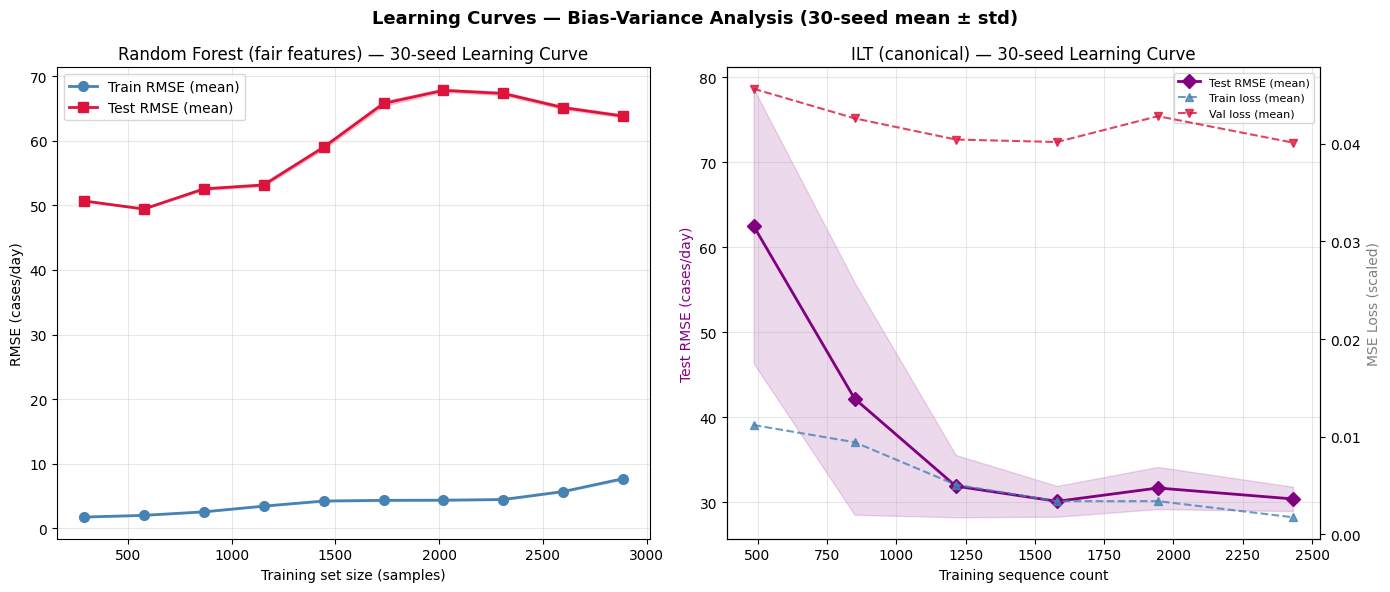

Saved plots/overfit_learning_curves_30SEED.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Learning Curves — Bias-Variance Analysis ({N_SEEDS}-seed mean ± std)', fontsize=13, fontweight='bold')

lc_rf_train_mean_a = np.array(lc_rf_train_mean); lc_rf_train_std_a = np.array(lc_rf_train_std)
lc_rf_test_mean_a = np.array(lc_rf_test_mean); lc_rf_test_std_a = np.array(lc_rf_test_std)
axes[0].plot(lc_n, lc_rf_train_mean_a, 'o-', color='steelblue', lw=2, ms=7, label='Train RMSE (mean)')
axes[0].fill_between(lc_n, lc_rf_train_mean_a - lc_rf_train_std_a, lc_rf_train_mean_a + lc_rf_train_std_a, color='steelblue', alpha=0.2)
axes[0].plot(lc_n, lc_rf_test_mean_a, 's-', color='crimson', lw=2, ms=7, label='Test RMSE (mean)')
axes[0].fill_between(lc_n, lc_rf_test_mean_a - lc_rf_test_std_a, lc_rf_test_mean_a + lc_rf_test_std_a, color='crimson', alpha=0.2)
axes[0].set_xlabel('Training set size (samples)'); axes[0].set_ylabel('RMSE (cases/day)')
axes[0].set_title(f'Random Forest (fair features) — {N_SEEDS}-seed Learning Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

lc_dl_test_rmse_mean_a = np.array(lc_dl_test_rmse_mean); lc_dl_test_rmse_std_a = np.array(lc_dl_test_rmse_std)
ax2 = axes[1]
ax2.plot(dl_lc_n, lc_dl_test_rmse_mean_a, 'D-', color='purple', lw=2, ms=7, label='Test RMSE (mean)')
ax2.fill_between(dl_lc_n, lc_dl_test_rmse_mean_a - lc_dl_test_rmse_std_a, lc_dl_test_rmse_mean_a + lc_dl_test_rmse_std_a, color='purple', alpha=0.15)
ax2b = ax2.twinx()
lc_dl_train_loss_mean_a = np.array(lc_dl_train_loss_mean); lc_dl_val_loss_mean_a = np.array(lc_dl_val_loss_mean)
ax2b.plot(dl_lc_n, lc_dl_train_loss_mean_a, '^--', color='steelblue', lw=1.5, ms=6, alpha=0.8, label='Train loss (mean)')
ax2b.plot(dl_lc_n, lc_dl_val_loss_mean_a, 'v--', color='crimson', lw=1.5, ms=6, alpha=0.8, label='Val loss (mean)')
ax2.set_xlabel('Training sequence count'); ax2.set_ylabel('Test RMSE (cases/day)', color='purple')
ax2b.set_ylabel('MSE Loss (scaled)', color='gray')
ax2.set_title(f'ILT (canonical) — {N_SEEDS}-seed Learning Curve')
l1, lb1 = ax2.get_legend_handles_labels(); l2, lb2 = ax2b.get_legend_handles_labels()
ax2.legend(l1 + l2, lb1 + lb2, fontsize=8, loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/overfit_learning_curves_30SEED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/overfit_learning_curves_30SEED.png")


## Section 3 — Training Curve Inspection (Illustrative Single Run)

A single, illustrative training curve per model at the canonical `seed=42`, kept for visual
inspection of *one* concrete run (early stopping, epochs=100, patience=20). This is **not** the
statistically rigorous version — that is Section 3.1 below, which repeats this exact training
recipe (minus early stopping) across all 30 seeds and reports the distribution.


In [12]:
print("Training ONE illustrative run per model at the canonical seed=42 "
      "(early stopping, epochs=100, patience=20) -- purely for the single-curve visualization "
      "below. The statistically rigorous version across all 30 seeds is Section 3.1.")

dl_runs = {}
for name, builder in model_builders:
    rmse, mae, r2, hist, model = train_once(
        builder, 42, Xts_seq, Xts_feat, yt, Xvs_seq, Xvs_feat, yv,
        X_te_s, X_te_f, y_te_raw, d['target_scaler'], SEQ_LEN,
        d['n_seq_features'], d['n_feat_features'], epochs=100, patience=20)
    best_ep = int(np.argmin(hist.history['val_loss']))
    dl_runs[name] = {'history': hist.history, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'model': model}
    print(f"{name:<18} (seed=42) — best_epoch={best_ep+1}/{len(hist.history['loss'])}, "
          f"train_loss={hist.history['loss'][best_ep]:.5f}, val_loss={hist.history['val_loss'][best_ep]:.5f}, "
          f"test RMSE={rmse:.2f}, R2={r2:.4f}")


Training ONE illustrative run per model at the canonical seed=42 (early stopping, epochs=100, patience=20) -- purely for the single-curve visualization below. The statistically rigorous version across all 30 seeds is Section 3.1.
Standalone LSTM    (seed=42) — best_epoch=2/22, train_loss=0.00484, val_loss=0.04484, test RMSE=31.27, R2=0.6946

ILT (proposed)     (seed=42) — best_epoch=7/27, train_loss=0.00152, val_loss=0.04008, test RMSE=31.21, R2=0.6957


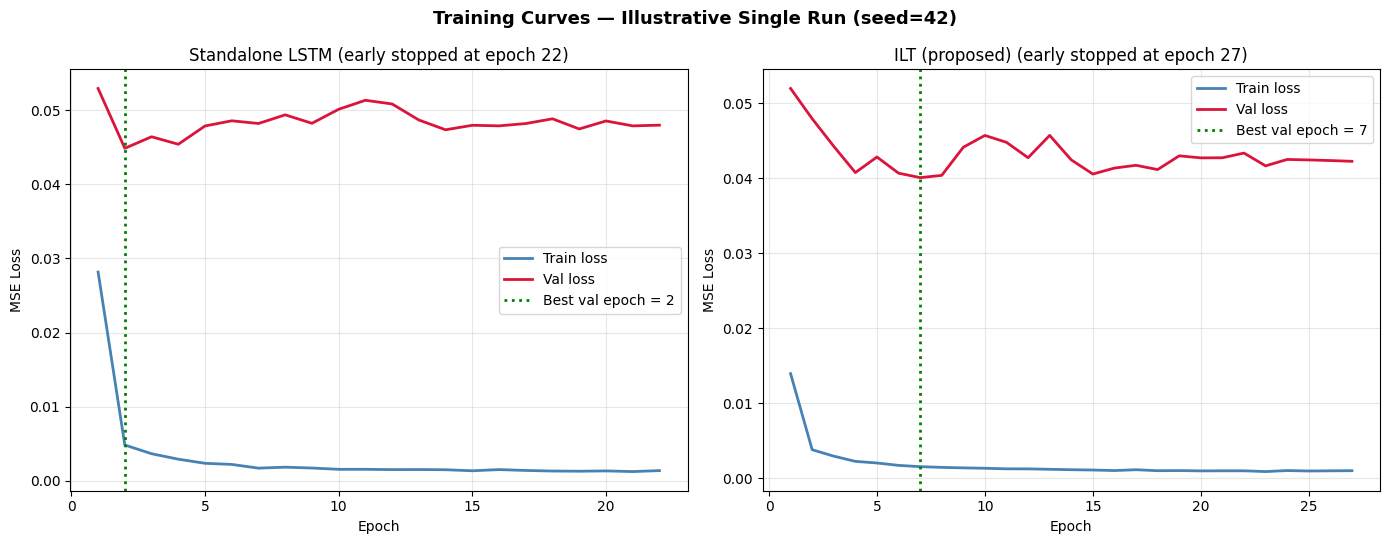

Saved plots/overfit_training_curve_seed42_illustrative.png


In [13]:
fig, axes = plt.subplots(1, len(model_builders), figsize=(7 * len(model_builders), 5.5))
fig.suptitle('Training Curves — Illustrative Single Run (seed=42)', fontsize=13, fontweight='bold')

for ax, (name, _) in zip(np.atleast_1d(axes), model_builders):
    h = dl_runs[name]['history']
    best_ep = int(np.argmin(h['val_loss']))
    ax.plot(range(1, len(h['loss']) + 1), h['loss'], label='Train loss', color='steelblue', lw=2)
    ax.plot(range(1, len(h['val_loss']) + 1), h['val_loss'], label='Val loss', color='crimson', lw=2)
    gline = ax.axvline(best_ep + 1, color='green', linestyle=':', lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.set_title(f'{name} (early stopped at epoch {len(h["loss"])})')
    ax.legend(['Train loss', 'Val loss', f'Best val epoch = {best_ep + 1}'])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/overfit_training_curve_seed42_illustrative.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/overfit_training_curve_seed42_illustrative.png")


## 3.1 — 30-Seed Boxplot: Overfitting Across Random Seeds (No Early Stopping, 120 Epochs)

**This is the core 30-seed analysis the redo was requested for.** It restores and extends an
earlier boxplot analysis whose source code was lost — only `metrics/overfit_boxplot_matrices.pkl`
and two PNGs (`plots/overfit_boxplot_3panel.png`, `plots/overfit_boxplot_ilt_single.png`) survived,
using the old pre-canonical model names (`Vanilla LSTM` / `Vanilla Transformer` / `LSTM-Transformer`)
and a non-canonical seed list (`range(30)`). Rebuilt here from scratch on the canonical
**Standalone LSTM** and **ILT (proposed)** models, using notebook 12's native 120-epoch budget:

- Both DL models train **30 independent times each** — one full run per canonical seed, **no
  early stopping**, fixed `epochs=120` (same total budget as the FIXED version's single Section
  3.1 run, just repeated 30×).
- At 24 fixed epoch checkpoints (5, 10, 15, ..., 120), the train/val loss across all 30 seeds is
  collected and boxplotted at that x-position, showing both the overfitting trend (train loss
  keeps dropping, val loss plateaus or rises) **and** how much that trend varies seed-to-seed.
- A **green dotted line** marks the "optimum point" — the epoch checkpoint where the *median*
  validation loss across the 30 seeds is lowest. This mirrors the curve-fitting example in
  course material 5.7.6 (green line = the just-right / ideal setting), except here the "curve"
  being read is the empirical median trend across 30 independent runs rather than a single fitted
  curve.
- Two charts are produced: a **2-panel comparison** (Standalone LSTM vs ILT side by side, **both**
  panels carry their own green optimum-epoch line) and a **separate, larger ILT-only chart** with
  the same green-line annotation, matching the surviving `overfit_boxplot_ilt_single.png` style.

⚠️ **This is the most expensive part of the notebook**: 30 seeds × 2 models × 120 epochs with no
early stopping ≈ 2–4 hours on CPU. The cell below checkpoints after every seed to
`metrics/overfit_boxplot_30seed_checkpoint.pkl` — safe to interrupt (kernel restart, laptop sleep,
etc.) and resume later; it will skip seeds already completed.


In [14]:
EXTENDED_EPOCHS = 120
CKPT_EPOCHS = list(range(5, EXTENDED_EPOCHS + 1, 5))   
BOXPLOT_CKPT_PATH = 'metrics/overfit_boxplot_30seed_checkpoint.pkl'
print(f"Epoch checkpoints ({len(CKPT_EPOCHS)}): {CKPT_EPOCHS}")


def train_no_earlystop(builder, seed, epochs):
    """ONE run, full epoch budget, NO early stopping (same recipe as the FIXED version's
    Section 3.1 extended-epoch run) -- returns only the per-epoch loss/val_loss lists."""
    tf.random.set_seed(seed); np.random.seed(seed)
    m = builder(SEQ_LEN, d['n_seq_features'], d['n_feat_features'])
    hist = m.fit([Xts_seq, Xts_feat], yt, validation_data=([Xvs_seq, Xvs_feat], yv),
                 epochs=epochs, batch_size=32, verbose=0)
    return hist.history['loss'], hist.history['val_loss']


def load_boxplot_ckpt():
    if os.path.exists(BOXPLOT_CKPT_PATH):
        with open(BOXPLOT_CKPT_PATH, 'rb') as f:
            return pickle.load(f)
    return {name: {'loss': [], 'val_loss': [], 'seed': []} for name, _ in model_builders}


def save_boxplot_ckpt(res):
    with open(BOXPLOT_CKPT_PATH, 'wb') as f:
        pickle.dump(res, f)


boxplot_results = load_boxplot_ckpt()
n_done = len(boxplot_results[model_builders[0][0]]['loss'])
print(f"Resuming 30-seed boxplot sweep: {n_done}/{N_SEEDS} seeds already done.")


Epoch checkpoints (24): [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120]
Resuming 30-seed boxplot sweep: 30/30 seeds already done.


In [15]:
t0 = time.time()
for i in range(n_done, N_SEEDS):
    seed = SEEDS[i]
    for name, builder in model_builders:
        loss, val_loss = train_no_earlystop(builder, seed, EXTENDED_EPOCHS)
        boxplot_results[name]['loss'].append(loss)
        boxplot_results[name]['val_loss'].append(val_loss)
        boxplot_results[name]['seed'].append(seed)
    save_boxplot_ckpt(boxplot_results)
    elapsed = time.time() - t0
    done = i - n_done + 1
    eta = elapsed / done * (N_SEEDS - i - 1) if done > 0 else 0
    print(f"  seed {i+1}/{N_SEEDS} (={seed}) done — elapsed {elapsed/60:.1f}min, ETA {eta/60:.1f}min")

print(f"\n30-seed sweep complete: {N_SEEDS} seeds x {len(model_builders)} models x "
      f"{EXTENDED_EPOCHS} epochs (no early stopping)")



30-seed sweep complete: 30 seeds x 2 models x 120 epochs (no early stopping)


In [16]:
# 一次性修補:把舊版 checkpoint 缺少的 'seed' 欄位補回去
for name, _ in model_builders:
    if 'seed' not in boxplot_results[name]:
        boxplot_results[name]['seed'] = [None] * len(boxplot_results[name]['loss'])
    if 'seed' not in dl_gap_results[name]:
        dl_gap_results[name]['seed'] = [None] * len(dl_gap_results[name]['test_rmse'])
for frac in fracs_dl:
    if 'seed' not in dl_lc_results[frac]:
        dl_lc_results[frac]['seed'] = [None] * len(dl_lc_results[frac]['test_rmse'])
print("已修補")

已修補


In [17]:
def build_checkpoint_matrix(histories_list, ckpt_epochs):
    """histories_list: list of N_SEEDS per-epoch loss lists -> returns (n_checkpoints, n_seeds) matrix."""
    mat = np.zeros((len(ckpt_epochs), len(histories_list)))
    for s, hist in enumerate(histories_list):
        for e_i, ep in enumerate(ckpt_epochs):
            mat[e_i, s] = hist[ep - 1]
    return mat


def find_best_val_epoch(val_mat, ckpt_epochs):
    """'Optimum point' = checkpoint epoch with the lowest MEDIAN validation loss across seeds."""
    median_val = np.median(val_mat, axis=1)
    return ckpt_epochs[int(np.argmin(median_val))]


boxplot_matrices = {}
for name, _ in model_builders:
    train_mat = build_checkpoint_matrix(boxplot_results[name]['loss'], CKPT_EPOCHS)
    val_mat = build_checkpoint_matrix(boxplot_results[name]['val_loss'], CKPT_EPOCHS)
    boxplot_matrices[name] = {'train': train_mat, 'val': val_mat}
    best_ep = find_best_val_epoch(val_mat, CKPT_EPOCHS)
    print(f"{name}: train_mat {train_mat.shape}, val_mat {val_mat.shape}, best val epoch (median) ≈ {best_ep}")

with open('metrics/overfit_boxplot_matrices_30SEED.pkl', 'wb') as f:
    pickle.dump({'matrices': boxplot_matrices, 'epoch_steps': CKPT_EPOCHS, 'n_seeds': N_SEEDS,
                 'seeds_used': {name: boxplot_results[name]['seed'] for name, _ in model_builders}}, f)
print("Saved metrics/overfit_boxplot_matrices_30SEED.pkl")


Standalone LSTM: train_mat (24, 30), val_mat (24, 30), best val epoch (median) ≈ 20
ILT (proposed): train_mat (24, 30), val_mat (24, 30), best val epoch (median) ≈ 15
Saved metrics/overfit_boxplot_matrices_30SEED.pkl


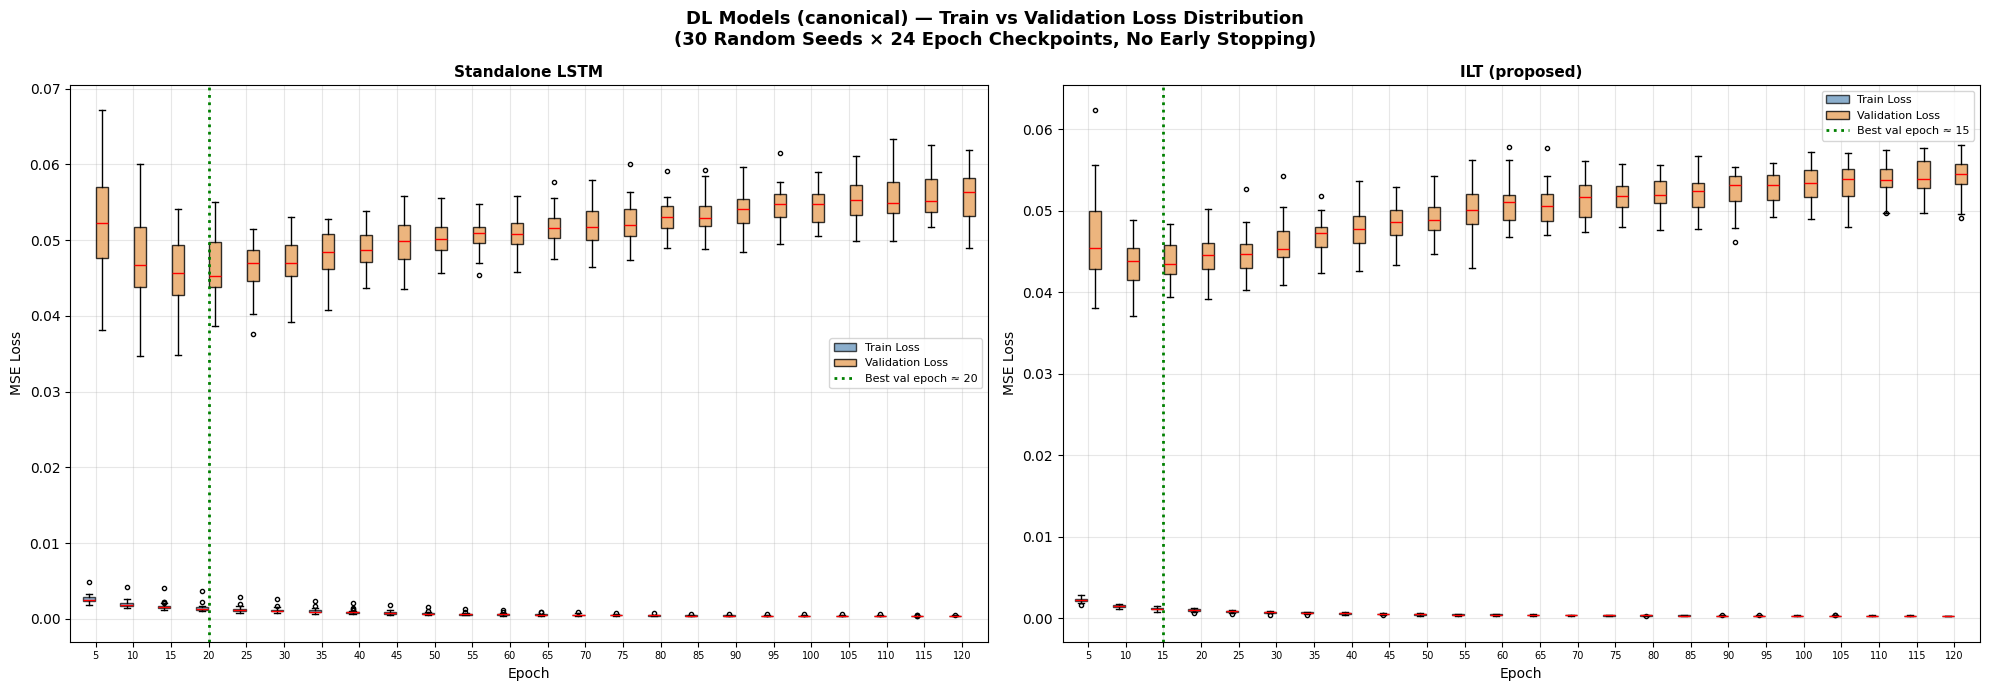

Saved plots/overfit_boxplot_2panel_30SEED.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(f'DL Models (canonical) — Train vs Validation Loss Distribution\n'
             f'({N_SEEDS} Random Seeds × {len(CKPT_EPOCHS)} Epoch Checkpoints, No Early Stopping)',
             fontsize=13, fontweight='bold')

model_order = [name for name, _ in model_builders]
for ax, name in zip(axes, model_order):
    train_mat = boxplot_matrices[name]['train']
    val_mat = boxplot_matrices[name]['val']
    best_ep = find_best_val_epoch(val_mat, CKPT_EPOCHS)
    positions = np.arange(len(CKPT_EPOCHS))
    bp_t = ax.boxplot(train_mat.T, positions=positions - 0.18, widths=0.32, patch_artist=True,
                       boxprops=dict(facecolor='#5B8DB8', alpha=0.7), medianprops=dict(color='red'),
                       flierprops=dict(markersize=3))
    bp_v = ax.boxplot(val_mat.T, positions=positions + 0.18, widths=0.32, patch_artist=True,
                       boxprops=dict(facecolor='#E8A35E', alpha=0.8), medianprops=dict(color='red'),
                       flierprops=dict(markersize=3))
    best_pos = CKPT_EPOCHS.index(best_ep)
    gline = ax.axvline(best_pos, color='green', linestyle=':', lw=2)
    ax.set_xticks(positions)
    ax.set_xticklabels([str(e) for e in CKPT_EPOCHS], rotation=0, fontsize=7)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.legend([bp_t['boxes'][0], bp_v['boxes'][0], gline],
              ['Train Loss', 'Validation Loss', f'Best val epoch ≈ {best_ep}'], fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/overfit_boxplot_2panel_30SEED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/overfit_boxplot_2panel_30SEED.png")


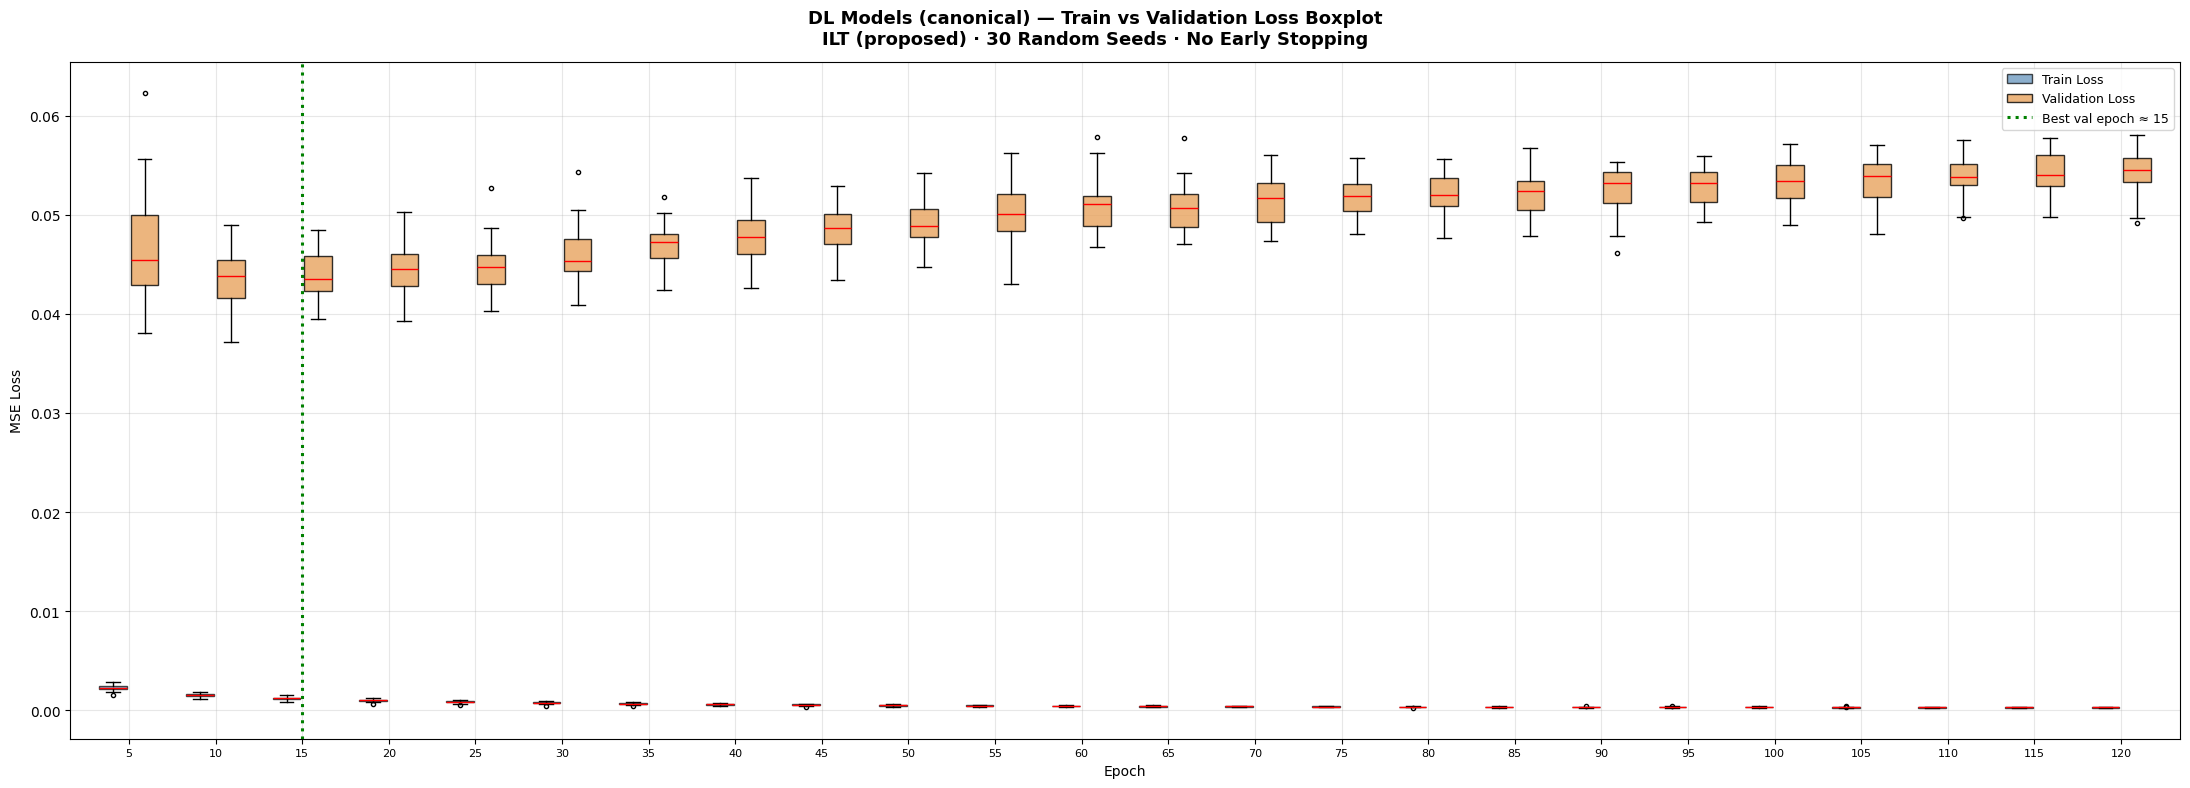

Saved plots/overfit_boxplot_ilt_single_30SEED.png


In [19]:
name = 'ILT (proposed)'
train_mat = boxplot_matrices[name]['train']
val_mat = boxplot_matrices[name]['val']
best_ep = find_best_val_epoch(val_mat, CKPT_EPOCHS)

fig, ax = plt.subplots(figsize=(22, 8))
positions = np.arange(len(CKPT_EPOCHS))
bp_t = ax.boxplot(train_mat.T, positions=positions - 0.18, widths=0.32, patch_artist=True,
                   boxprops=dict(facecolor='#5B8DB8', alpha=0.7), medianprops=dict(color='red'),
                   flierprops=dict(markersize=3))
bp_v = ax.boxplot(val_mat.T, positions=positions + 0.18, widths=0.32, patch_artist=True,
                   boxprops=dict(facecolor='#E8A35E', alpha=0.8), medianprops=dict(color='red'),
                   flierprops=dict(markersize=3))
best_pos = CKPT_EPOCHS.index(best_ep)
gline = ax.axvline(best_pos, color='green', linestyle=':', lw=2.2)
ax.set_xticks(positions)
ax.set_xticklabels([str(e) for e in CKPT_EPOCHS], fontsize=8)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
fig.suptitle(f'DL Models (canonical) — Train vs Validation Loss Boxplot\n'
             f'ILT (proposed) · {N_SEEDS} Random Seeds · No Early Stopping', fontsize=13, fontweight='bold')
ax.legend([bp_t['boxes'][0], bp_v['boxes'][0], gline],
          ['Train Loss', 'Validation Loss', f'Best val epoch ≈ {best_ep}'], fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/overfit_boxplot_ilt_single_30SEED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/overfit_boxplot_ilt_single_30SEED.png")


## Section 4 — Residual Analysis

Uses the illustrative seed=42 run from Section 3 (and the cached seed=42 Random Forest fit) as a
representative example for residual diagnostics. This section is about residual *shape*
(heteroscedasticity, autocorrelation) rather than seed variability, so a single representative
run is appropriate here — the seed-to-seed variability itself is already covered by Sections 1–3.1.


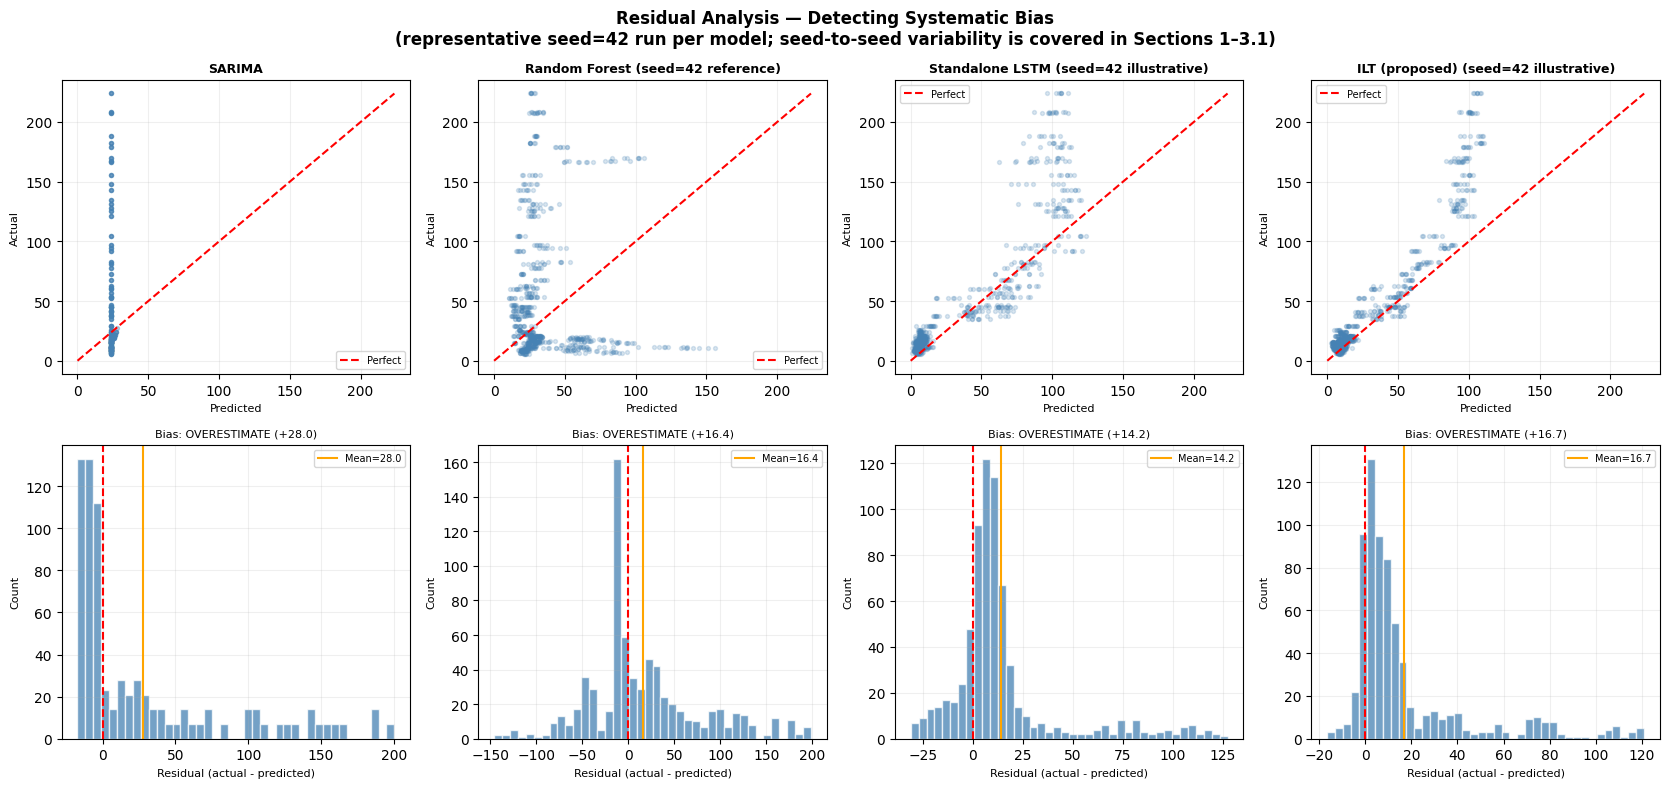

Saved plots/overfit_residuals_30SEED.png


In [20]:
eval_models = [
    ('SARIMA', sarima_results['predictions'], d['y_test']),
    ('Random Forest (seed=42 reference)', rf_results['predictions'], y_r_te),
]
for name, _ in model_builders:
    m = dl_runs[name]['model']
    pred_s = m.predict([X_te_s, X_te_f], verbose=0).flatten()
    preds = np.maximum(d['target_scaler'].inverse_transform(pred_s.reshape(-1, 1)).flatten(), 0)
    eval_models.append((f'{name} (seed=42 illustrative)', preds, y_te_raw))

fig, axes = plt.subplots(2, len(eval_models), figsize=(4.2 * len(eval_models), 8))
fig.suptitle('Residual Analysis — Detecting Systematic Bias\n(representative seed=42 run per model; seed-to-seed variability is covered in Sections 1–3.1)',
             fontsize=12, fontweight='bold')

for col, (name, preds, y_true) in enumerate(eval_models):
    preds, y_true = np.asarray(preds), np.asarray(y_true)
    min_len = min(len(preds), len(y_true))
    preds_a, y_true_a = preds[-min_len:], y_true[-min_len:]
    residuals = y_true_a - preds_a
    ax_s, ax_h = axes[0][col], axes[1][col]
    lim = max(y_true_a.max(), preds_a.max())
    ax_s.scatter(preds_a, y_true_a, alpha=0.2, s=8, color='steelblue')
    ax_s.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
    ax_s.set_xlabel('Predicted', fontsize=8); ax_s.set_ylabel('Actual', fontsize=8)
    ax_s.set_title(name, fontsize=9, fontweight='bold'); ax_s.legend(fontsize=7); ax_s.grid(alpha=0.2)
    ax_h.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.75)
    ax_h.axvline(0, color='red', lw=1.5, linestyle='--')
    ax_h.axvline(residuals.mean(), color='orange', lw=1.5, label=f'Mean={residuals.mean():.1f}')
    ax_h.set_xlabel('Residual (actual - predicted)', fontsize=8); ax_h.set_ylabel('Count', fontsize=8)
    ax_h.legend(fontsize=7); ax_h.grid(alpha=0.2)
    bias_tag = 'OVERESTIMATE' if residuals.mean() > 5 else ('UNDERESTIMATE' if residuals.mean() < -5 else 'NEUTRAL')
    ax_h.set_title(f'Bias: {bias_tag} ({residuals.mean():+.1f})', fontsize=8)

plt.tight_layout()
plt.savefig('plots/overfit_residuals_30SEED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plots/overfit_residuals_30SEED.png")


## Section 5 — Overfitting/Underfitting Verdict (30-Seed Aggregate)

The verdict for each model is now based on **30-seed aggregate evidence**: mean ± std train/val
gap, the fraction of seeds showing a meaningful gap, and the median-curve best epoch / whether the
median validation loss clearly rises after that point over the full 120-epoch sweep.


In [21]:
print("=" * 90)
print(f"  OVERFITTING / UNDERFITTING RISK CLASSIFICATION (canonical models, {N_SEEDS}-seed Monte Carlo)")
print("=" * 90)

verdicts = [
    ('SARIMA', 'Statistical', 'UNDERFITTING',
     f"R2={sarima_results['R2']:.3f} (single deterministic run)",
     'Model too simple for non-linear dengue dynamics'),
    ('Random Forest (fair)', 'ML',
     ('SEVERE OVERFITTING' if (rf_train_r2_mean > 0.8 and rf_test_r2_mean < 0)
      else 'MILD OVERFITTING' if (rf_train_rmse_mean < rf_test_rmse_mean * 0.5)
      else 'ACCEPTABLE'),
     f"{N_SEEDS}-seed mean: Train RMSE={rf_train_rmse_mean:.1f}±{rf_train_rmse_std:.1f} "
     f"(R2={rf_train_r2_mean:.3f}) vs Test RMSE={rf_test_rmse_mean:.1f}±{rf_test_rmse_std:.1f} "
     f"(R2={rf_test_r2_mean:.3f})",
     'Tree ensembles memorise on weather-only features with near-zero true signal; '
     'min_samples_leaf=5/max_depth=12 limit tree depth but do not fix the severe train/test gap'),
]

for name, _ in model_builders:
    bt = np.array(dl_gap_results[name]['best_train_loss'])
    bv = np.array(dl_gap_results[name]['best_val_loss'])
    gap = bv - bt
    n_overfit_seeds = int((gap > 0.01).sum())
    val_mat = boxplot_matrices[name]['val']
    best_ckpt_idx = int(np.argmin(np.median(val_mat, axis=1)))
    rises_after_best = bool(
        np.median(val_mat[-1]) > np.median(val_mat[best_ckpt_idx]) * 1.1
    ) if best_ckpt_idx < len(CKPT_EPOCHS) - 1 else False

    if gap.mean() > 0.01:
        verdict = 'MILD OVERFITTING'
    elif bv.mean() > 0.03:
        verdict = 'UNDERFITTING'
    else:
        verdict = 'WELL-REGULARISED'

    evidence = (f"{N_SEEDS}-seed mean val-train gap={gap.mean():+.5f}±{gap.std():.5f} "
                f"({n_overfit_seeds}/{N_SEEDS} seeds with gap>0.01); "
                f"120-epoch no-early-stop sweep: median val loss best at epoch≈{CKPT_EPOCHS[best_ckpt_idx]}, "
                f"{'rises' if rises_after_best else 'plateaus / does not clearly rise'} by epoch 120")
    verdicts.append((name, 'DL', verdict, evidence,
                     'Dropout(0.2) + EarlyStopping(patience=20) + LayerNorm + gradient clipping'))

print(f"\n{'Model':<22} {'Type':<14} {'Verdict':<20} Evidence")
print('-' * 140)
for name, mtype, verdict, evidence, mitigation in verdicts:
    print(f"{name:<22} {mtype:<14} {verdict:<20} {evidence}")
    print(f"   Mitigation: {mitigation}\n")

overfit_summary = {
    'n_seeds': N_SEEDS,
    'seeds_used': {
        'random_forest_gap': rf_30['seed'],
        'dl_gap': {name: dl_gap_results[name]['seed'] for name, _ in model_builders},
        'boxplot_sweep': {name: boxplot_results[name]['seed'] for name, _ in model_builders},
    },
    'verdicts': verdicts,
    'rf_30': rf_30,
    'rf_learning_curve': {'n': lc_n, 'train_mean': lc_rf_train_mean, 'train_std': lc_rf_train_std,
                           'test_mean': lc_rf_test_mean, 'test_std': lc_rf_test_std},
    'dl_learning_curve': {'n': dl_lc_n, 'train_loss_mean': lc_dl_train_loss_mean,
                           'val_loss_mean': lc_dl_val_loss_mean, 'test_rmse_mean': lc_dl_test_rmse_mean},
    'gap_table': gap_df.to_dict(),
    'dl_gap_results': dl_gap_results,
    'boxplot_matrices': boxplot_matrices,
    'boxplot_epoch_steps': CKPT_EPOCHS,
}
with open('metrics/overfit_analysis_30SEED.pkl', 'wb') as f:
    pickle.dump(overfit_summary, f)

print("Saved metrics/overfit_analysis_30SEED.pkl")
print("\nPlots generated:")
print("   plots/overfit_train_test_gap_30SEED.png")
print("   plots/overfit_learning_curves_30SEED.png")
print("   plots/overfit_training_curve_seed42_illustrative.png")
print("   plots/overfit_boxplot_2panel_30SEED.png")
print("   plots/overfit_boxplot_ilt_single_30SEED.png")
print("   plots/overfit_residuals_30SEED.png")


  OVERFITTING / UNDERFITTING RISK CLASSIFICATION (canonical models, 30-seed Monte Carlo)

Model                  Type           Verdict              Evidence
--------------------------------------------------------------------------------------------------------------------------------------------
SARIMA                 Statistical    UNDERFITTING         R2=-0.257 (single deterministic run)
   Mitigation: Model too simple for non-linear dengue dynamics

Random Forest (fair)   ML             SEVERE OVERFITTING   30-seed mean: Train RMSE=7.7±0.2 (R2=0.962) vs Test RMSE=63.8±0.2 (R2=-0.308)
   Mitigation: Tree ensembles memorise on weather-only features with near-zero true signal; min_samples_leaf=5/max_depth=12 limit tree depth but do not fix the severe train/test gap

Standalone LSTM        DL             MILD OVERFITTING     30-seed mean val-train gap=+0.04020±0.00325 (30/30 seeds with gap>0.01); 120-epoch no-early-stop sweep: median val loss best at epoch≈20, rises by epoch 120
   Mi

In [22]:
# ── [ADDED] Checkpoint train/val gap at epochs 30/60/90/120 (30-seed mean) → metrics/overfit_checkpoints_30_60_90_120_FIXED.csv ──
# Reproducible from this notebook's boxplot_matrices (fixed seeds); CKPT_EPOCHS = [5,10,...,120].
import numpy as _np, pandas as _pd
_targets=[30,60,90,120]; _rows=[]
for _name in boxplot_matrices:
    _tr=_np.asarray(boxplot_matrices[_name]['train']); _va=_np.asarray(boxplot_matrices[_name]['val'])
    _best=CKPT_EPOCHS[int(_np.argmin(_va.mean(axis=1)))]; _prev=None
    for _e in _targets:
        _i=CKPT_EPOCHS.index(_e); _tl=float(_tr[_i].mean()); _vl=float(_va[_i].mean()); _g=_vl-_tl
        _rows.append({'Model':_name,'Epoch':_e,'Train Loss':round(_tl,6),'Val Loss':round(_vl,6),
                      'Gap (Val-Train)':round(_g,6),'Gap d vs prev':(None if _prev is None else round(_g-_prev,6)),
                      'Best epoch so far':_best}); _prev=_g
_ovA=_pd.DataFrame(_rows); _ovA.to_csv('metrics/overfit_checkpoints_30_60_90_120_FIXED.csv',index=False)
print("OK saved metrics/overfit_checkpoints_30_60_90_120_FIXED.csv"); print(_ovA.to_string(index=False))


OK saved metrics/overfit_checkpoints_30_60_90_120_FIXED.csv
          Model  Epoch  Train Loss  Val Loss  Gap (Val-Train)  Gap d vs prev  Best epoch so far
Standalone LSTM     30    0.001131  0.046976         0.045845            NaN                 15
Standalone LSTM     60    0.000595  0.050981         0.050385       0.004540                 15
Standalone LSTM     90    0.000411  0.053926         0.053515       0.003129                 15
Standalone LSTM    120    0.000365  0.055834         0.055469       0.001954                 15
 ILT (proposed)     30    0.000746  0.045851         0.045105            NaN                 10
 ILT (proposed)     60    0.000423  0.050785         0.050362       0.005257                 10
 ILT (proposed)     90    0.000313  0.052478         0.052165       0.001803                 10
 ILT (proposed)    120    0.000268  0.054211         0.053943       0.001779                 10


In [23]:
# ── [ADDED] RF (fair, weather-only) Train vs Test by horizon, 30 fixed seeds → metrics/rf_feature_parity_multihorizon.csv ──
# Reproducible from this notebook's fair-RF data dict `d` + SEEDS. Demonstrates SEVERE overfit (train R2>>test R2).
from sklearn.ensemble import RandomForestRegressor as _RF
from sklearn.metrics import mean_squared_error as _mse, r2_score as _r2s
import numpy as _np, pandas as _pd
_Xtr,_ytr,_Xte,_yte = d['X_train_rf'], d['y_train'], d['X_test_rf'], d['y_test']
_rows=[]
for _h in [1,7,14,21,28]:
    _xtr,_ytn=_Xtr[:-_h],_ytr[_h:]; _xte,_ytt=_Xte[:-_h],_yte[_h:]
    _a,_b,_c,_e=[],[],[],[]
    for _s in SEEDS:
        _m=_RF(n_estimators=300,max_depth=12,min_samples_split=10,min_samples_leaf=5,max_features='sqrt',random_state=_s,n_jobs=-1)
        _m.fit(_xtr,_ytn); _ptr,_pte=_m.predict(_xtr),_m.predict(_xte)
        _a.append(_np.sqrt(_mse(_ytn,_ptr))); _b.append(_r2s(_ytn,_ptr)); _c.append(_np.sqrt(_mse(_ytt,_pte))); _e.append(_r2s(_ytt,_pte))
    _rows.append({'horizon':_h,'rf_weather_train_rmse':round(_np.mean(_a),4),'rf_weather_train_r2':round(_np.mean(_b),4),
                  'rf_weather_test_rmse':round(_np.mean(_c),4),'rf_weather_test_r2':round(_np.mean(_e),4)})
    print(f"  h={_h:>2}d train RMSE={_np.mean(_a):.2f} R2={_np.mean(_b):.3f} | test RMSE={_np.mean(_c):.2f} R2={_np.mean(_e):.3f}")
_rfC=_pd.DataFrame(_rows); _rfC.to_csv('metrics/rf_feature_parity_multihorizon.csv',index=False)
print("OK saved metrics/rf_feature_parity_multihorizon.csv")


  h= 1d train RMSE=7.70 R2=0.962 | test RMSE=63.83 R2=-0.308
  h= 7d train RMSE=7.61 R2=0.963 | test RMSE=64.43 R2=-0.325
  h=14d train RMSE=7.90 R2=0.960 | test RMSE=65.06 R2=-0.341
  h=21d train RMSE=7.61 R2=0.963 | test RMSE=65.98 R2=-0.371
  h=28d train RMSE=7.82 R2=0.961 | test RMSE=66.28 R2=-0.374
OK saved metrics/rf_feature_parity_multihorizon.csv
